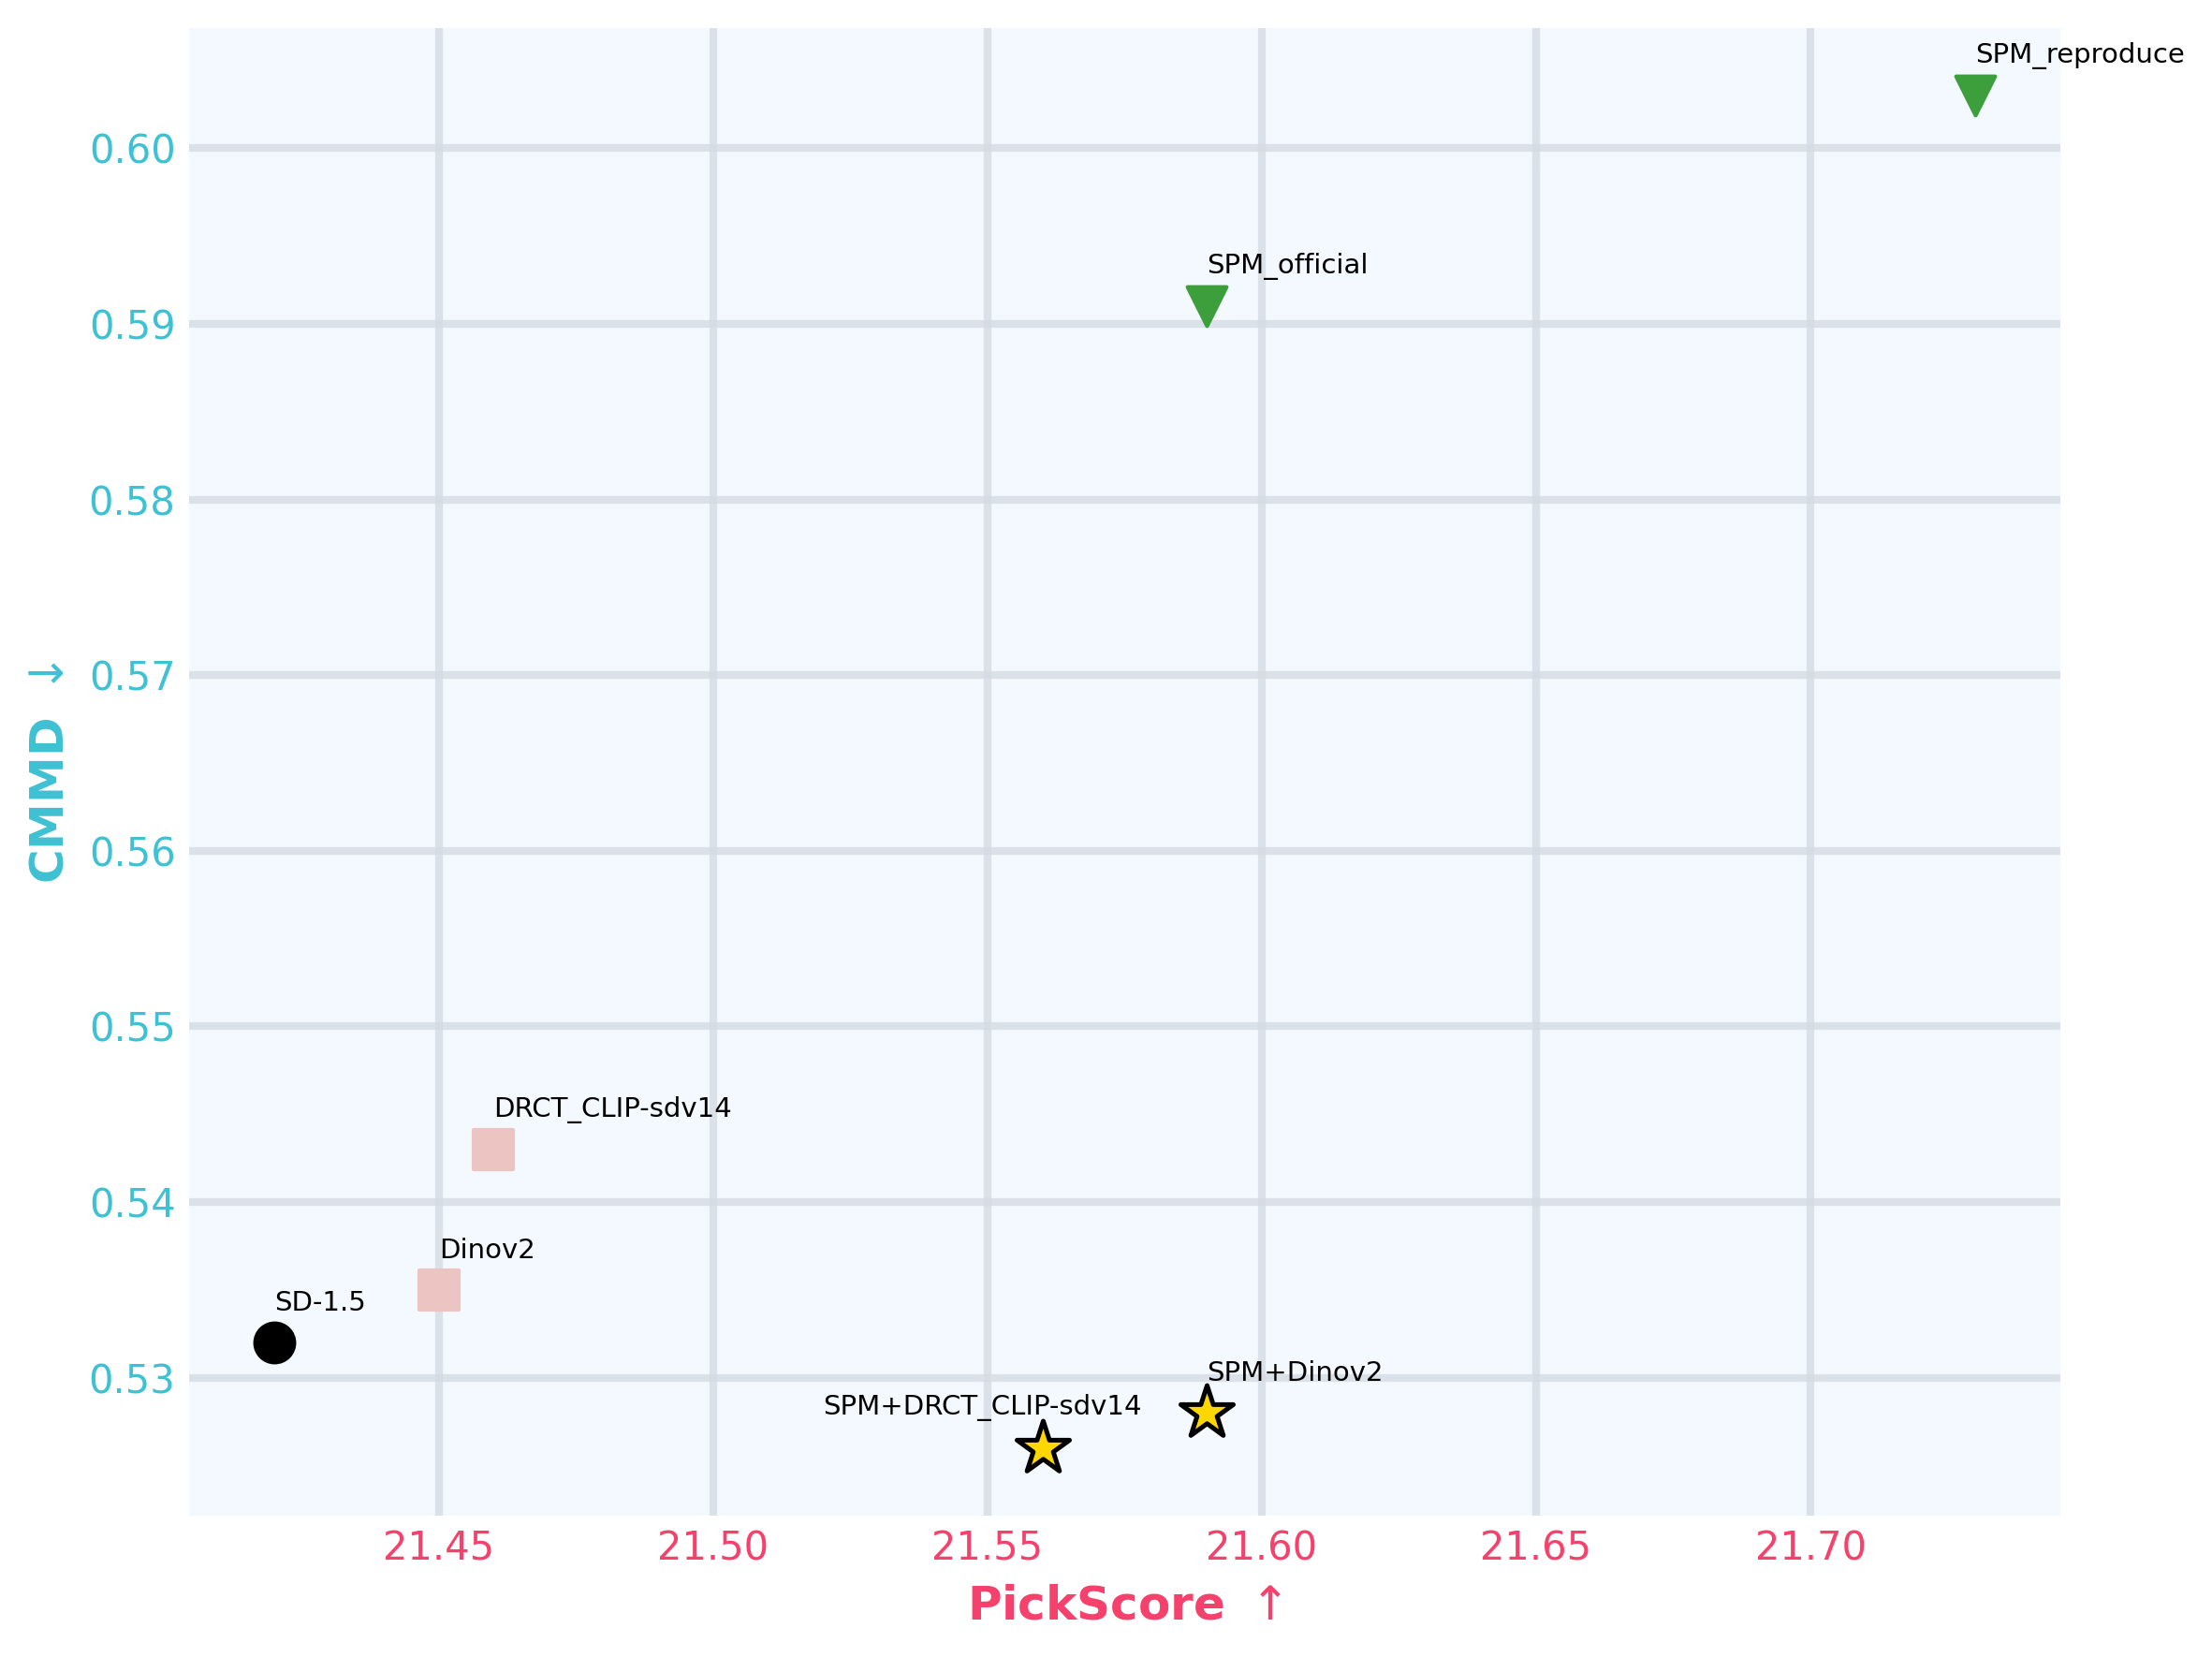

In [16]:
# mscoco_val_2014_10k
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

methods = ["SD-1.5", "SPM_official", "SPM_reproduce", "Dinov2", "DRCT_CLIP-sdv14", "SPM+Dinov2", "SPM+DRCT_CLIP-sdv14"]
FID = [19.60, 26.08, 23.21, 20.07, 20.00, 19.63, 19.55]
CMMD = [0.532, 0.591, 0.603, 0.535, 0.543, 0.528, 0.526]
PICKSCORE = [21.42, 21.59, 21.73, 21.45, 21.46, 21.59, 21.56]
reality = CMMD
human_preference = PICKSCORE


plt.figure(figsize=(8, 6), dpi=300)
ax = plt.gca()
ax.set_facecolor("#f3f9fe") # background color
# grid
ax.grid(True, linestyle="-", color="#d6dbe3", alpha=0.8, linewidth=2, zorder=0)

for i, method in enumerate(methods):
    if method not in [ "SPM+Dinov2", "SPM+DRCT_CLIP-sdv14" ]:
        if method in ["Dinov2", "DRCT_CLIP-sdv14"]:
            marker, color = "s", "#ecc4c2"
        elif method in ["SPM_official", "SPM_reproduce"]:
            marker, color = "v", "#3d9f3c"
        elif method == "SD-1.5":
            marker, color = "o", "black"
            
        plt.scatter(human_preference[i], reality[i], color=color, marker=marker, s=100, zorder=3)
        plt.text(human_preference[i], reality[i]+0.0015, f"{method}",
                    fontsize=7, ha="left", va="bottom")

# special point(yellow star)：SPM+Dinov2
method = methods[5]
plt.scatter(human_preference[5], reality[5], color="gold", marker="*", s=200, edgecolor="black", linewidth=1.2, zorder=3)
plt.text(human_preference[5], reality[5]+0.0015, f"{method}",
         fontsize=7, ha="left", va="bottom")

# special point(yellow star)：SPM+DRCT_CLIP-sdv14
method = methods[6]
plt.scatter(human_preference[6], reality[6], color="gold", marker="*", s=200, edgecolor="black", linewidth=1.2, zorder=3)
plt.text(human_preference[6]-0.11+0.07, reality[6]+0.0015, f"{method}",
         fontsize=7, ha="left", va="bottom")


# remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)
ax.tick_params(axis="x", colors="#f6416c") 
ax.tick_params(axis="y", colors="#3ec1d3")

# blue_arrow = FancyArrowPatch(
#     posA=(0.280, 0.675),
#     posB=(0.283, 0.50),
#     connectionstyle="arc3,rad=-0.4",
#     arrowstyle="-|>,head_length=8,head_width=5",
#     color="#3ec1d3",
#     linewidth=3,
#     mutation_scale=2,
#     zorder=3
# )
# ax.add_patch(blue_arrow)

# ax.text(0.2825, 0.64, "Lower CMMD \nBetter Image Quality",
#         fontsize=10, fontweight='bold', color='#3ec1d3',
#         ha='center', va='center')


# red_arrow = FancyArrowPatch(
#     posA=(0.2795, 0.65),        
#     posB=(0.2825, 0.475),       
#     connectionstyle="arc3,rad=0.4",
#     arrowstyle="-|>,head_length=8,head_width=5",
#     color="#f6416c",
#     linewidth=3,
#     mutation_scale=2,
#     zorder=3
# )
# ax.add_patch(red_arrow)
# ax.text(0.2805, 0.475, "Higher HPSv2 \nBetter Human Preference",
#         fontsize=10, fontweight='bold', color='#f6416c',
#         ha='center', va='bottom')

ax.set_xlabel(r'PickScore $\uparrow$', color="#f6416c", fontsize=12, fontweight='bold')
ax.set_ylabel(r'CMMD $\downarrow$', color="#3ec1d3", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
